# Bird Migration — Phase 2&4: Feature Engineering & Data cleaning
**Author:** Jayant Pandey  
**Project:** Bird Migration GPS Tracking — ISI Kolkata IDEAS Internship 2026  

- 61,920 GPS records across 3 White Storks (Eric, Nico, Sanne)
- Aug 2013 to Apr 2014
- Columns: latitude, longitude, altitude, speed_2d, direction, bird_name, date_time, unix_timestamp, day_of_year, hour, temperature, wind_speed, precipitation
- Zero nulls

**Phase 4 adds:** 33 engineered features for K-Means clustering and ML classification

**Phase 4 produces:** `bird_migration_features.csv`

## 0. Imports

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print('Imports done.')

Imports done.


## 1. Load Output Data set
Loading `bird_migration_with_cleaned.csv`

In [3]:
df = pd.read_csv('bird_migration_cleaned.csv')
df['date_time'] = pd.to_datetime(df['date_time'], utc=True)
df = df.sort_values(['bird_name', 'date_time']).reset_index(drop=True)
print('Phase 1 output loaded successfully.')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Nulls:', df.isnull().sum().sum())
df.head(3)

Phase 1 output loaded successfully.
Shape: (61920, 10)
Columns: ['altitude', 'date_time', 'device_info_serial', 'direction', 'latitude', 'longitude', 'speed_2d', 'bird_name', 'altitude_flag', 'speed_flag']
Nulls: 0


,altitude,date_time,device_info_serial,direction,latitude,longitude,speed_2d,bird_name,altitude_flag,speed_flag
0,71,2013-08-15 00:18:08+00:00,851,-150.469753,49.41986,2.120733,0.150000,Eric,0,0
1,68,2013-08-15 00:48:07+00:00,851,-136.151141,49.41988,2.120746,2.438360,Eric,0,0
2,68,2013-08-15 01:17:58+00:00,851,160.797477,49.42031,2.120885,0.596657,Eric,0,0


##### Fix 3 null values in speed_2d (Sanne, last 3 records — April 2014)
##### Forward fill within each bird group 

In [4]:

df['speed_2d'] = df.groupby('bird_name')['speed_2d'].transform(lambda x: x.ffill())

print('Nulls in speed_2d after fix:', df['speed_2d'].isnull().sum())
print('Total nulls in dataset:', df.isnull().sum().sum())

Nulls in speed_2d after fix: 0
Total nulls in dataset: 0


In [5]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


In [6]:
df['direction'] = df.groupby('bird_name')['direction'].transform(lambda x: x.ffill())

print('Nulls in direction after fix:', df['direction'].isnull().sum())
print('Total nulls in dataset:', df.isnull().sum().sum())

Nulls in direction after fix: 0
Total nulls in dataset: 0


#### 1.2 Duplicate Check
Check for duplicate records — same bird at same timestamp — before feature engineering begins.

In [7]:
exact_dupes = df.duplicated().sum()
print('Exact duplicate rows:', exact_dupes)


key_dupes = df.duplicated(subset=['bird_name', 'date_time']).sum()
print('Duplicate bird + timestamp combinations:', key_dupes)

if key_dupes > 0:
    mask = df.duplicated(subset=['bird_name', 'date_time'], keep=False)
    print(df[mask][['bird_name', 'date_time', 'latitude', 'longitude']].head(10))
    df = df.drop_duplicates(subset=['bird_name', 'date_time'], keep='first').reset_index(drop=True)
    print('Duplicates removed. New shape:', df.shape)
else:
    print('No duplicates found. Shape unchanged:', df.shape)

Exact duplicate rows: 0
Duplicate bird + timestamp combinations: 0
No duplicates found. Shape unchanged: (61920, 10)


## 1.3 Coordinate Validation
#### Validating coordinate ranges

Latitude is bounded by [-90°, +90°] — South Pole to North Pole.  
Longitude is bounded by [-180°, +180°] — International Date Line to Date Line.  
Any GPS reading outside these ranges is physically impossible and indicates a sensor error.  
Records with invalid coordinates are removed before feature engineering.

In [8]:
invalid_lat = df[(df['latitude'] < -90) | (df['latitude'] > 90)]
invalid_lon = df[(df['longitude'] < -180) | (df['longitude'] > 180)]

print('Invalid latitude values:', len(invalid_lat))
print('Invalid longitude values:', len(invalid_lon))

if len(invalid_lat) == 0 and len(invalid_lon) == 0:
    print('All coordinates within valid geographic range.')
else:
    df = df[
        (df['latitude'].between(-90, 90)) &
        (df['longitude'].between(-180, 180))
    ].reset_index(drop=True)
    print('Invalid coordinates removed. New shape:', df.shape)

Invalid latitude values: 0
Invalid longitude values: 0
All coordinates within valid geographic range.


## 2. Temporal Features

Extract time-based features and apply cyclic (sin/cos) encoding.

**Why cyclic encoding?**  
Hour 23 and Hour 0 are 1 hour apart but numerically 23 apart. Standard encoding misleads the model. Sin/cos encoding wraps the cycle correctly — 23:00 and 00:00 are treated as close.

In [9]:
df['hour']        = df['date_time'].dt.hour
df['day_of_year'] = df['date_time'].dt.dayofyear
df['month']       = df['date_time'].dt.month

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_sin']  = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['day_cos']  = np.cos(2 * np.pi * df['day_of_year'] / 365)

print('Temporal features added.')
df[['hour', 'day_of_year', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']].head(3)

Temporal features added.


,hour,day_of_year,hour_sin,hour_cos,day_sin,day_cos
0,0,227,0.000000,1.000000,-0.693281,-0.720667
1,0,227,0.000000,1.000000,-0.693281,-0.720667
2,1,227,0.258819,0.965926,-0.693281,-0.720667


## 3. Season Encoding

Three biological seasons based on date:
- **1 = Autumn migration** (Aug–Nov 2013) — southward journey
- **2 = Wintering** (Dec 2013–Jan 2014) — resting in West Africa
- **3 = Spring return** (Feb–Apr 2014) — northward journey

In [10]:
def encode_season(month):
    if month in [8, 9, 10, 11]:
        return 1
    elif month in [12, 1]:
        return 2
    else:
        return 3

df['season'] = df['month'].apply(encode_season)

print('Season distribution:')
print(df['season'].value_counts().sort_index())
print('1=Autumn migration, 2=Wintering, 3=Spring return')

Season distribution:
season
1    25934
2    15265
3    20721
Name: count, dtype: int64
1=Autumn migration, 2=Wintering, 3=Spring return


## 4. Time Delta

Time elapsed (seconds) between consecutive GPS observations per bird.

**Why?** GPS is not sampled at perfectly equal intervals. Acceleration and distance features depend on elapsed time. Time_Delta gives models this context explicitly.

In [11]:
df['unix_timestamp'] = df['date_time'].astype(np.int64) // 10**9
df['time_delta'] = df.groupby('bird_name')['unix_timestamp'].diff().fillna(0)

print('Time delta stats (seconds):')
print(df['time_delta'].describe())

Time delta stats (seconds):
count    61920.000000
mean         1.084109
std          2.226778
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        400.000000
Name: time_delta, dtype: float64


#### Outlier check: Time Delta (upper tail)

Time delta — high percentiles (seconds):
0.900    2.0
0.950    2.0
0.990    2.0
0.999    4.0
Name: time_delta, dtype: float64

Records with time_delta above 99th percentile: 262
      bird_name                 date_time  time_delta
6528       Eric 2013-11-10 12:17:46+00:00       400.0
5993       Eric 2013-10-30 11:46:10+00:00       365.0
39249      Nico 2014-04-08 01:44:15+00:00        12.0
40764      Nico 2014-04-28 07:24:45+00:00         9.0
40765      Nico 2014-04-28 09:26:00+00:00         8.0
45955     Sanne 2013-10-15 23:01:38+00:00         8.0
496        Eric 2013-08-20 23:27:49+00:00         6.0
53659     Sanne 2014-01-19 01:30:50+00:00         6.0
28407      Nico 2013-11-27 03:35:50+00:00         6.0
33583      Nico 2014-01-29 01:33:15+00:00         6.0


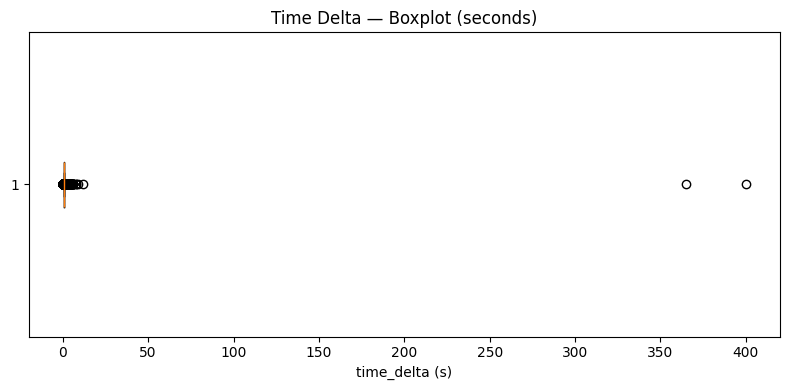

In [12]:
import matplotlib.pyplot as plt

print('Time delta — high percentiles (seconds):')
print(df['time_delta'].quantile([0.90, 0.95, 0.99, 0.999]))

large_gaps = df[df['time_delta'] > df['time_delta'].quantile(0.99)]
print(f"\nRecords with time_delta above 99th percentile: {len(large_gaps)}")
print(large_gaps[['bird_name', 'date_time', 'time_delta']].sort_values('time_delta', ascending=False).head(10))

plt.figure(figsize=(8, 4))
plt.boxplot(df['time_delta'], vert=False)
plt.title('Time Delta — Boxplot (seconds)')
plt.xlabel('time_delta (s)')
plt.tight_layout()
plt.show()


## 5. Kinematic Features

Describe **how** the bird is moving — not just where it is.

These are among the most important features because migration behaviour (active flying vs resting at stopovers) is captured in movement dynamics, not just position.

### 5.1 Haversine Distance  
**Great‑circle distance (km)** between consecutive GPS points  
We are using the *Haversine formula* — accounts for Earth’s curvature.


In [13]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

lat_prev = df.groupby('bird_name')['latitude'].shift(1)
lon_prev = df.groupby('bird_name')['longitude'].shift(1)

df['haversine_dist'] = haversine(
    lat_prev.fillna(df['latitude']),
    lon_prev.fillna(df['longitude']),
    df['latitude'],
    df['longitude']
)

print('Haversine distance (km):')
print(df['haversine_dist'].describe())

Haversine distance (km):
count    61920.000000
mean         1.115219
std          2.971018
min          0.000000
25%          0.013226
50%          0.078487
75%          0.487353
max         78.698804
Name: haversine_dist, dtype: float64


#### Outlier check: Haversine Distance (upper tail)

Haversine distance — high percentiles (km):
0.900     3.480726
0.950     6.754553
0.990    14.328383
0.999    28.138046
Name: haversine_dist, dtype: float64

Records with haversine_dist above 99th percentile: 620
      bird_name                 date_time  haversine_dist  time_delta
6975       Eric 2013-11-15 21:27:20+00:00       78.698804         2.0
44392     Sanne 2013-09-27 03:15:48+00:00       62.226926         5.0
27673      Nico 2013-11-18 03:15:29+00:00       50.862077         3.0
42839     Sanne 2013-09-07 22:30:48+00:00       48.957733         4.0
18315      Eric 2014-04-01 21:57:52+00:00       47.343552         2.0
7145       Eric 2013-11-18 03:17:19+00:00       46.500279         5.0
27508      Nico 2013-11-16 02:48:10+00:00       46.376587         2.0
27507      Nico 2013-11-16 02:18:15+00:00       46.204528         2.0
27500      Nico 2013-11-15 22:48:25+00:00       45.440752         2.0
27499      Nico 2013-11-15 22:17:59+00:00       44.871327         1.0


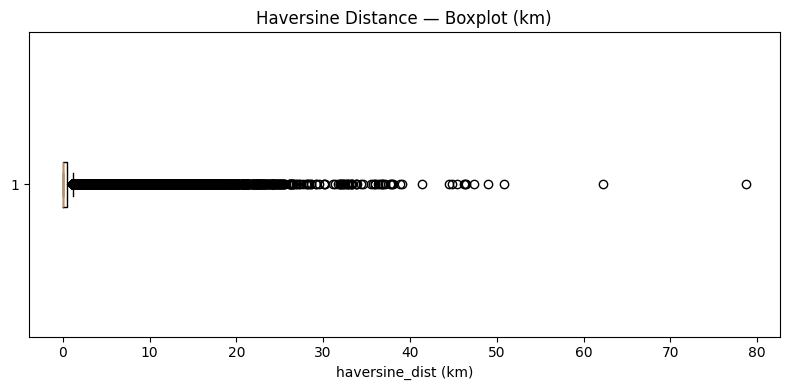

In [14]:
import matplotlib.pyplot as plt

print('Haversine distance — high percentiles (km):')
print(df['haversine_dist'].quantile([0.90, 0.95, 0.99, 0.999]))

large_jumps = df[df['haversine_dist'] > df['haversine_dist'].quantile(0.99)]
print(f"\nRecords with haversine_dist above 99th percentile: {len(large_jumps)}")
print(large_jumps[['bird_name', 'date_time', 'haversine_dist', 'time_delta']].sort_values('haversine_dist', ascending=False).head(10))

plt.figure(figsize=(8, 4))
plt.boxplot(df['haversine_dist'], vert=False)
plt.title('Haversine Distance — Boxplot (km)')
plt.xlabel('haversine_dist (km)')
plt.tight_layout()
plt.show()


#### 5.2 Bearing
Direction of travel between consecutive GPS fixes (0-360 degrees)  
0=North, 90=East, 180=South, 270=West


In [15]:
def compute_bearing(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    bearing = np.degrees(np.arctan2(x, y))
    return (bearing + 360) % 360

df['bearing'] = compute_bearing(
    lat_prev.fillna(df['latitude']),
    lon_prev.fillna(df['longitude']),
    df['latitude'],
    df['longitude']
)

print('Bearing (degrees 0-360):')
print(df['bearing'].describe())

Bearing (degrees 0-360):
count    61920.000000
mean       180.192870
std        103.632518
min          0.000000
25%         92.800267
50%        181.732397
75%        267.127242
max        359.994180
Name: bearing, dtype: float64


### 5.3 Acceleration 
Rate of change in speed between consecutive observations (m/s²)

In [16]:


speed_prev = df.groupby('bird_name')['speed_2d'].shift(1)

df['acceleration'] = (
    (df['speed_2d'] - speed_prev.fillna(df['speed_2d'])) /
    df['time_delta'].replace(0, np.nan)
).fillna(0)

print('Acceleration (m/s²):')
print(df['acceleration'].describe())

Acceleration (m/s²):
count    61920.000000
mean        -0.002603
std          4.009201
min        -61.954834
25%         -0.990507
50%          0.000000
75%          1.009437
max         59.944889
Name: acceleration, dtype: float64


#### Outlier check: Acceleration (upper tail, by magnitude)

Acceleration — high percentiles of |acceleration| (m/s²):
0.900     6.032170
0.950     8.790676
0.990    14.861212
0.999    29.383401
Name: acceleration, dtype: float64

Records with |acceleration| above 99th percentile: 620
      bird_name                 date_time  acceleration  time_delta
8468       Eric 2013-12-04 06:10:48+00:00    -61.954834         1.0
8467       Eric 2013-12-04 05:55:54+00:00     59.944889         1.0
11904      Eric 2014-01-14 12:05:54+00:00     57.555931         1.0
11905      Eric 2014-01-14 12:20:48+00:00    -56.802412         1.0
52182     Sanne 2013-12-31 17:50:45+00:00     56.755206         1.0
12781      Eric 2014-01-25 03:00:02+00:00     53.532520         1.0
12782      Eric 2014-01-25 03:14:58+00:00    -52.897013         1.0
8904       Eric 2013-12-09 10:50:35+00:00    -51.089249         1.0
15792      Eric 2014-03-02 10:19:19+00:00     50.398007         1.0
49493     Sanne 2013-11-28 07:51:35+00:00    -50.319528         1.0


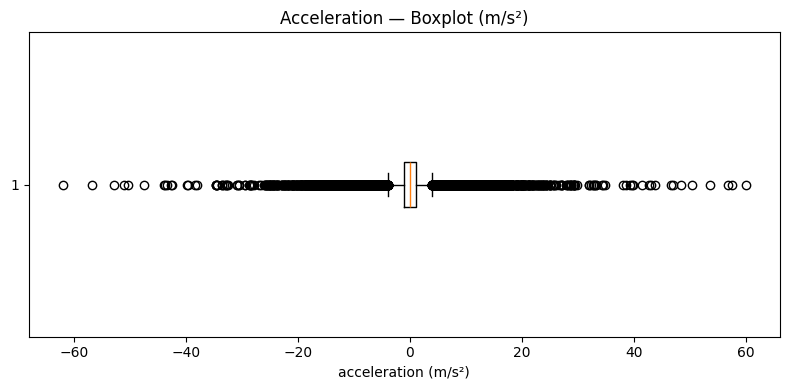

In [17]:
import matplotlib.pyplot as plt

print('Acceleration — high percentiles of |acceleration| (m/s²):')
print(df['acceleration'].abs().quantile([0.90, 0.95, 0.99, 0.999]))

accel_spikes = df[df['acceleration'].abs() > df['acceleration'].abs().quantile(0.99)]
print(f"\nRecords with |acceleration| above 99th percentile: {len(accel_spikes)}")
print(accel_spikes[['bird_name', 'date_time', 'acceleration', 'time_delta']]
      .reindex(accel_spikes['acceleration'].abs().sort_values(ascending=False).index)
      .head(10))

plt.figure(figsize=(8, 4))
plt.boxplot(df['acceleration'], vert=False)
plt.title('Acceleration — Boxplot (m/s²)')
plt.xlabel('acceleration (m/s²)')
plt.tight_layout()
plt.show()


### 5.4 Turning Rate 
 How fast the bird is changing direction (degrees per second)
 High turning rate = active manoeuvring; Low = straight migration flight

In [18]:
bearing_prev = df.groupby('bird_name')['bearing'].shift(1)
bearing_diff = (df['bearing'] - bearing_prev.fillna(df['bearing'])).abs()
bearing_diff = bearing_diff.apply(lambda x: x if x <= 180 else 360 - x)

df['turning_rate'] = (
    bearing_diff / df['time_delta'].replace(0, np.nan)
).fillna(0)

print('Turning rate (degrees/second):')
print(df['turning_rate'].describe())

Turning rate (degrees/second):
count    61920.000000
mean        67.340102
std         58.114993
min          0.000000
25%         13.324323
50%         53.745669
75%        116.330090
max        179.998806
Name: turning_rate, dtype: float64


#### Outlier check: Turning Rate (upper tail)

Turning rate — high percentiles (deg/s):
0.900    160.334603
0.950    171.247030
0.990    178.414192
0.999    179.842320
Name: turning_rate, dtype: float64

Records with turning_rate above 99th percentile: 620
      bird_name                 date_time  turning_rate  time_delta
13842      Eric 2014-02-06 19:03:49+00:00    179.998806         1.0
10297      Eric 2013-12-26 05:05:02+00:00    179.991938         1.0
2529       Eric 2013-09-14 10:14:08+00:00    179.990650         1.0
10916      Eric 2014-01-02 14:10:04+00:00    179.989441         1.0
41655     Sanne 2013-08-24 05:21:02+00:00    179.989159         1.0
24728      Nico 2013-10-13 09:37:45+00:00    179.984820         1.0
15883      Eric 2014-03-03 12:12:25+00:00    179.980883         1.0
8052       Eric 2013-11-29 06:01:04+00:00    179.972745         1.0
8436       Eric 2013-12-03 19:10:08+00:00    179.972553         1.0
426        Eric 2013-08-20 04:08:26+00:00    179.967458         1.0


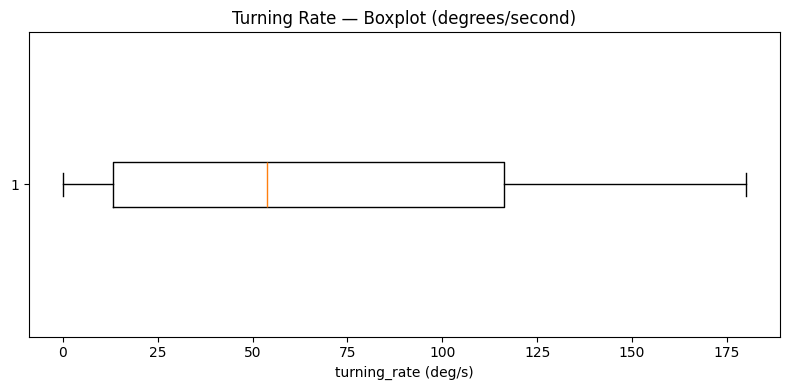

In [19]:
import matplotlib.pyplot as plt

print('Turning rate — high percentiles (deg/s):')
print(df['turning_rate'].quantile([0.90, 0.95, 0.99, 0.999]))

turn_spikes = df[df['turning_rate'] > df['turning_rate'].quantile(0.99)]
print(f"\nRecords with turning_rate above 99th percentile: {len(turn_spikes)}")
print(turn_spikes[['bird_name', 'date_time', 'turning_rate', 'time_delta']].sort_values('turning_rate', ascending=False).head(10))

plt.figure(figsize=(8, 4))
plt.boxplot(df['turning_rate'], vert=False)
plt.title('Turning Rate — Boxplot (degrees/second)')
plt.xlabel('turning_rate (deg/s)')
plt.tight_layout()
plt.show()


###  5.5 Is Resting Flag 
 Binary: 1 if speed < 1 m/s (anchored/resting), 0 if actively moving
 EDA finding: 44.9% of records have speed < 1 m/s

### Resting Behaviour Feature Summary

The `is_resting` feature was created using a threshold of **1.0 m/s** on horizontal speed (`speed_2d`).

This threshold was selected after examining the empirical speed distribution, which showed a strong concentration of observations at low speeds followed by a gradual decline toward higher flight speeds.

The resulting feature classified:

- **Resting observations:** 28,018 (45.25%)
- **Active observations:** 33,902 (54.75%)

The relatively balanced distribution suggests that the feature provides useful behavioural information for downstream machine learning models while remaining simple and interpretable.

Speed Statistics
count    61920.000000
mean         2.558697
std          3.577043
min          0.000000
25%          0.410000
50%          1.209318
75%          3.057924
max         63.488066
Name: speed_2d, dtype: float64

Selected Percentiles
0.01    0.044721
0.05    0.106301
0.10    0.170294
0.25    0.410000
0.50    1.209318
Name: speed_2d, dtype: float64


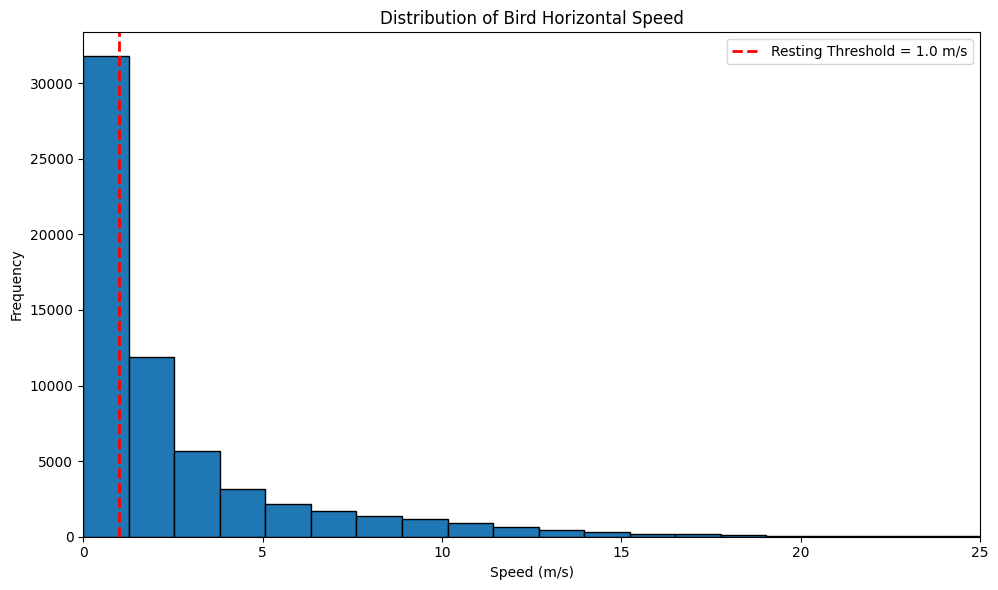

In [20]:
import matplotlib.pyplot as plt
print("=" * 60)
print("Speed Statistics")
print("=" * 60)

print(df['speed_2d'].describe())
print("\nSelected Percentiles")
print(df['speed_2d'].quantile([0.01, 0.05, 0.10, 0.25, 0.50]))
plt.figure(figsize=(10,6))
plt.hist(df['speed_2d'].dropna(),
         bins=50,
         edgecolor='black')

plt.axvline(
    x=1.0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Resting Threshold = 1.0 m/s'
)
plt.title("Distribution of Bird Horizontal Speed")
plt.xlabel("Speed (m/s)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
import os
os.makedirs("figures", exist_ok=True)
plt.savefig(
    "figures/Figure_01_Bird_Speed_Distribution_Full.png",
    dpi=300,
    bbox_inches="tight"
)
plt.xlim(0, 25)
plt.show()

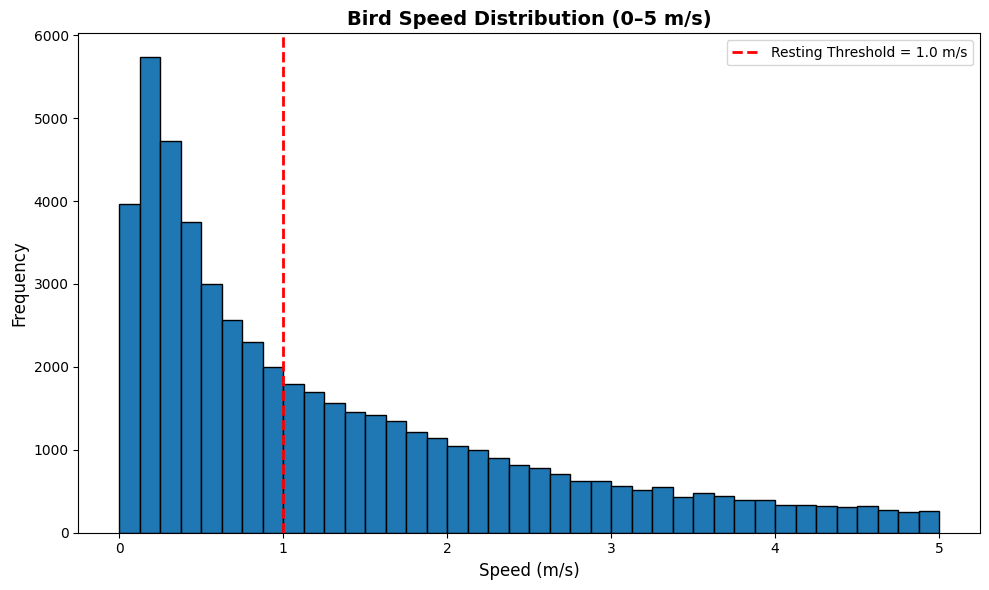

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    df[df['speed_2d'] <= 5]['speed_2d'],
    bins=40,
    edgecolor='black'
)

plt.axvline(
    1.0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Resting Threshold = 1.0 m/s'
)

plt.title("Bird Speed Distribution (0–5 m/s)", fontsize=14, fontweight='bold')
plt.xlabel("Speed (m/s)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()


plt.tight_layout()


plt.savefig(
    "bird_speed_distribution_0_5ms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
df['is_resting'] = (df['speed_2d'] < 1.0).astype(int)
print('Resting records:', df['is_resting'].sum())
print('Moving records:', (df['is_resting'] == 0).sum())
print('Resting percentage:', round(df['is_resting'].mean() * 100, 1), '%')

Resting records: 28021
Moving records: 33899
Resting percentage: 45.3 %


In [23]:
#  import os
#  os.makedirs("figures", exist_ok=True)

In [24]:
plt.savefig(
    "figures/Figure_2_Bird_Speed_Distribution_0_5ms.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [25]:
print(df['speed_2d'].describe())

print("\nPercentiles")

print(df['speed_2d'].quantile([
    0.01,
    0.05,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
]))

count    61920.000000
mean         2.558697
std          3.577043
min          0.000000
25%          0.410000
50%          1.209318
75%          3.057924
max         63.488066
Name: speed_2d, dtype: float64

Percentiles
0.01     0.044721
0.05     0.106301
0.10     0.170294
0.25     0.410000
0.50     1.209318
0.75     3.057924
0.90     7.146218
0.95    10.078443
0.99    16.010979
Name: speed_2d, dtype: float64


### Resting behaviour summary

In [26]:

resting_counts = df['is_resting'].value_counts().sort_index()

print(resting_counts)

print("\nPercentages")

print((df['is_resting']
       .value_counts(normalize=True)
       .sort_index()*100)
      .round(2))

is_resting
0    33899
1    28021
Name: count, dtype: int64

Percentages
is_resting
0    54.75
1    45.25
Name: proportion, dtype: float64


## 6. Outlier Flagging

Identified during Phase 1 EDA:
- Altitude: -1010m (below sea level) and +6965m (near Everest) — GPS sensor errors
- Speed: 63.5 m/s (228 km/h) — physically impossible for a stork

Flagged with binary columns rather than removed — they do not affect the classification features directly.

In [27]:
df['altitude_outlier'] = ((df['altitude'] < -1000) | (df['altitude'] > 6900)).astype(int)
df['speed_outlier']    = (df['speed_2d'] > 60).astype(int)

print('Altitude outliers flagged:', df['altitude_outlier'].sum())
print('Speed outliers flagged:', df['speed_outlier'].sum())
print('\nAltitude outlier values:')
print(df[df['altitude_outlier'] == 1][['bird_name', 'date_time', 'latitude', 'longitude', 'altitude']])

print('\nSpeed outlier value:')
print(df[df['speed_outlier'] == 1][['bird_name', 'date_time', 'latitude', 'longitude', 'speed_2d']])


before_shape = df.shape
df = df[(df['altitude_outlier'] == 0) & (df['speed_outlier'] == 0)].reset_index(drop=True)
print('\nShape before removal:', before_shape)
print('Shape after removal :', df.shape)
print('Rows removed         :', before_shape[0] - df.shape[0])


Altitude outliers flagged: 2
Speed outliers flagged: 1

Altitude outlier values:
      bird_name                 date_time   latitude  longitude  altitude
38968      Nico 2014-04-04 11:13:47+00:00  12.729490 -17.253060      6965
55608     Sanne 2014-02-11 17:00:57+00:00  14.945072 -17.112842     -1010

Speed outlier value:
     bird_name                 date_time   latitude  longitude   speed_2d
8467      Eric 2013-12-04 05:55:54+00:00  30.429814  -9.641887  63.488066

Shape before removal: (61920, 27)
Shape after removal : (61917, 27)
Rows removed         : 3


## 7. Lag Features

Give classical ML models short-term memory — what was the bird doing 1 and 2 timesteps ago?

**Why?** Unlike GRU which has built-in memory via hidden states, Random Forest and XGBoost have no memory. Lag features explicitly provide recent history as input columns — this is the standard technique to give classical ML models temporal awareness.

In [28]:
for col in ['latitude', 'longitude', 'speed_2d', 'bearing']:
    df[f'{col}_lag1'] = df.groupby('bird_name')[col].shift(1)
    df[f'{col}_lag2'] = df.groupby('bird_name')[col].shift(2)

lag_cols = [c for c in df.columns if 'lag' in c]
df[lag_cols] = df[lag_cols].fillna(0)

print('Lag features added:')
print(lag_cols)

Lag features added:
['altitude_flag', 'speed_flag', 'latitude_lag1', 'latitude_lag2', 'longitude_lag1', 'longitude_lag2', 'speed_2d_lag1', 'speed_2d_lag2', 'bearing_lag1', 'bearing_lag2']


## 8. Rolling Features

Moving averages and standard deviations over a window of 5 readings to smooth GPS noise.

**Why window=5?** GPS records are approximately every 30 minutes. A window of 5 covers ~2.5 hours — enough to capture short-term behaviour patterns without smoothing away meaningful variation.

In [29]:
WINDOW = 5
df['rolling_mean_speed']   = df.groupby('bird_name')['speed_2d'].transform(
    lambda x: x.rolling(WINDOW, min_periods=1).mean()
)
df['rolling_std_speed']    = df.groupby('bird_name')['speed_2d'].transform(
    lambda x: x.rolling(WINDOW, min_periods=1).std()
).fillna(0)
df['rolling_mean_heading'] = df.groupby('bird_name')['bearing'].transform(
    lambda x: x.rolling(WINDOW, min_periods=1).mean()
)
print('Rolling features added (window=5).')
df[['rolling_mean_speed', 'rolling_std_speed', 'rolling_mean_heading']].describe()

Rolling features added (window=5).


,rolling_mean_speed,rolling_std_speed,rolling_mean_heading
count,61917.000000,61917.000000,61917.000000
mean,2.557658,2.393018,180.182167
std,2.170926,2.073780,53.766916
min,0.055078,0.000000,0.000000
25%,1.129598,0.921930,146.485433
50%,1.946578,1.766802,182.487317
75%,3.278295,3.336484,215.878883
max,25.901660,25.493008,354.450377


In [30]:
print('temperature' in df.columns)
print('wind_speed' in df.columns)
print(df.shape)

False
False
(61917, 38)


## 9. Environmental Change Features

Rate of change in environmental conditions between consecutive GPS readings.

**Why?** A bird deciding to migrate responds to changing weather, not just current weather. Temperature dropping 5°C overnight is more informative than absolute temperature = 15°C.

In [31]:
df['altitude_change'] = df.groupby('bird_name')['altitude'].diff().fillna(0)
print('Altitude change feature added.')
df[['altitude_change']].describe()

Altitude change feature added.


,altitude_change
count,61917.000000
mean,-0.007752
std,105.273166
min,-6140.000000
25%,-11.000000
50%,0.000000
75%,11.000000
max,6182.000000


In [32]:
df.drop(columns=['temperature', 'wind_speed', 'precipitation',
                 'temperature_change', 'wind_speed_change'], 
        errors='ignore', inplace=True)

## 10. Final Feature Summary

In [33]:
SPATIAL     = ['latitude', 'longitude', 'altitude']
KINEMATIC   = ['speed_2d', 'bearing', 'acceleration', 'turning_rate',
               'haversine_dist', 'is_resting']
TEMPORAL    = ['hour', 'day_of_year', 'month', 'hour_sin', 'hour_cos',
               'day_sin', 'day_cos', 'season', 'time_delta']
LAG         = ['latitude_lag1', 'latitude_lag2',
               'longitude_lag1', 'longitude_lag2',
               'speed_2d_lag1', 'speed_2d_lag2',
               'bearing_lag1', 'bearing_lag2']
ROLLING     = ['rolling_mean_speed', 'rolling_std_speed', 'rolling_mean_heading']
ENVIRONMENT = ['altitude_change']
CATEGORICAL = ['bird_name']
FLAGS       = ['altitude_outlier', 'speed_outlier']

ALL_FEATURES = SPATIAL + KINEMATIC + TEMPORAL + LAG + ROLLING + ENVIRONMENT + CATEGORICAL + FLAGS

print('=== FEATURE ENGINEERING SUMMARY ===')
print(f'Spatial:          {len(SPATIAL):>3} features  — where the bird is')
print(f'Kinematic:        {len(KINEMATIC):>3} features  — how the bird is moving')
print(f'Temporal:         {len(TEMPORAL):>3} features  — when it is moving')
print(f'Lag:              {len(LAG):>3} features  — what it was doing recently')
print(f'Rolling:          {len(ROLLING):>3} features  — smoothed behaviour summaries')
print(f'Environmental:    {len(ENVIRONMENT):>3} features  — surrounding conditions')
print(f'Categorical:      {len(CATEGORICAL):>3} feature   — bird identity')
print(f'Flags:            {len(FLAGS):>3} features  — sensor error indicators')
print(f'-----------------------------------')
print(f'Total:            {len(ALL_FEATURES):>3} features')
print()

null_check = df[ALL_FEATURES].isnull().sum()
if null_check.sum() == 0:
    print('Null check: PASSED — zero nulls across all features')
else:
    print('Null check: FAILED — nulls found:')
    print(null_check[null_check > 0])


=== FEATURE ENGINEERING SUMMARY ===
Spatial:            3 features  — where the bird is
Kinematic:          6 features  — how the bird is moving
Temporal:           9 features  — when it is moving
Lag:                8 features  — what it was doing recently
Rolling:            3 features  — smoothed behaviour summaries
Environmental:      1 features  — surrounding conditions
Categorical:        1 feature   — bird identity
Flags:              2 features  — sensor error indicators
-----------------------------------
Total:             33 features

Null check: PASSED — zero nulls across all features


## 11. Saving the Output for Phase 5

In [35]:
SAVE_COLS = ['date_time', 'unix_timestamp'] + ALL_FEATURES
SAVE_COLS = list(dict.fromkeys(SAVE_COLS))

df[SAVE_COLS].to_csv('bird_migration_features.csv', index=False)

print('Saved: bird_migration_features.csv')
print('Shape:', df[SAVE_COLS].shape)
print()
print('Next: Phase 5 — K-Means Clustering on lat/lon to create migration zones')

Saved: bird_migration_features.csv
Shape: (61917, 35)

Next: Phase 5 — K-Means Clustering on lat/lon to create migration zones
